# 예상 대비 거래 차이 기반 고객 군집화

회귀 노트북(`04_regression_final.ipynb`)에서 이미 학습·저장한 **모델 B(금액 제외, 조기경보용)**의 예측 결과(`gap_result_B.pkl`)를 그대로 불러와 사용합니다. 이 노트북에서는 회귀 모델을 다시 학습하지 않고, 저장된 **예상 대비 거래 차이(활동성 갭)**를 군집 피처로 사용합니다.

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples

SEED = 42
KMEANS_SILHOUETTE_TARGET = 0.4
GMM_SILHOUETTE_TARGET = 0.3

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 로드

정제된 원본 데이터만 불러옵니다. 회귀 피처(X)를 별도로 구성할 필요가 없습니다 — 예측값은 이미 `gap_result_B.pkl`에 저장되어 있기 때문입니다.

In [6]:
df = pd.read_csv("../data/processed/bankchurners_clean.csv")

print("원본 데이터:", df.shape)
df["Total_Trans_Ct"].describe()

원본 데이터: (10127, 20)


count    10127.000000
mean        64.858695
std         23.472570
min         10.000000
25%         45.000000
50%         67.000000
75%         81.000000
max        139.000000
Name: Total_Trans_Ct, dtype: float64

## 2. 회귀 결과(활동성 갭) 불러오기

`04_regression_final.ipynb`에서 모델 B(거래금액 제외, 조기경보용)로 이미 계산해 저장해둔 예측 거래건수·활동성 갭을 `pickle`로 불러와 원본 데이터에 붙입니다. 회귀 모델을 다시 학습하지 않으므로, 이 노트북은 **전체 고객(Train/Validation/Test 구분 없이)**을 대상으로 군집화를 진행합니다.

In [7]:
with open("../outputs/gap_result/gap_result_B.pkl", "rb") as f:
    gap_result_B = pickle.load(f)

df = df.join(gap_result_B)  # 인덱스 기준으로 자동 매칭되어 붙음

print("갭 결과 결합 후:", df.shape)
df[["Total_Trans_Ct", "예측_거래건수_B", "활동성_갭_B"]].describe().round(2)

갭 결과 결합 후: (10127, 22)


,Total_Trans_Ct,예측_거래건수_B,활동성_갭_B
count,10127.00,10127.00,10127.00
mean,64.86,64.85,0.01
std,23.47,12.34,19.38
min,10.00,24.52,-81.33
25%,45.00,58.06,-12.88
50%,67.00,64.66,1.29
75%,81.00,70.14,12.62
max,139.00,109.55,75.93


## 3. 예상 대비 거래 차이(cluster_df) 구성

**예상 대비 거래 차이 = 실제 거래건수 − 예측 거래건수(모델 B 기준)**
- 음수: 예상보다 적게 거래함 → 활동 급감 위험 신호
- 양수: 예상보다 많이 거래함 → 우량 고객 신호

회귀를 다시 학습하지 않으므로, 전체 고객을 대상으로 `cluster_df`를 만듭니다.

In [8]:
cluster_df = pd.DataFrame({
    "고객ID": df.index,
    "실제_거래건수": df["Total_Trans_Ct"].values,
    "예측_거래건수": df["예측_거래건수_B"].values,
    "예상_대비_거래_차이": df["활동성_갭_B"].values,
    "실제_이탈여부": df["Target"].values,
}, index=df.index)

cluster_df[[
    "실제_거래건수", "예측_거래건수", "예상_대비_거래_차이", "실제_이탈여부"
]].describe().round(2)

,실제_거래건수,예측_거래건수,예상_대비_거래_차이,실제_이탈여부
count,10127.00,10127.00,10127.00,10127.00
mean,64.86,64.85,0.01,0.16
std,23.47,12.34,19.38,0.37
min,10.00,24.52,-81.33,0.00
25%,45.00,58.06,-12.88,0.00
50%,67.00,64.66,1.29,0.00
75%,81.00,70.14,12.62,0.00
max,139.00,109.55,75.93,1.00


## 4. 군집 피처 표준화

예상 대비 거래 차이와 실제 거래건수는 범위가 다르므로 `StandardScaler`로 평균 0, 표준편차 1이 되도록 변환합니다.
표준화하지 않으면 값의 범위가 큰 피처가 거리 계산을 지배할 수 있습니다.

In [9]:
cluster_cols = ["예상_대비_거래_차이", "실제_거래건수"]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(cluster_df[cluster_cols])

pd.DataFrame(X_cluster_scaled, columns=cluster_cols).describe().round(2)

,예상_대비_거래_차이,실제_거래건수
count,10127.00,10127.00
mean,0.00,-0.00
std,1.00,1.00
min,-4.20,-2.34
25%,-0.67,-0.85
50%,0.07,0.09
75%,0.65,0.69
max,3.92,3.16


## 5. KMeans 최적 군집 수 탐색

군집 수 `k=2~8`을 비교합니다. 각 결과의 Silhouette Score를 계산하며, 1에 가까울수록 군집 내부는 응집되고 군집 간에는 잘 분리되었다는 뜻입니다.

In [10]:
kmeans_rows = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = model.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels)
    kmeans_rows.append({
        "모델": "KMeans",
        "설정": f"k={k}",
        "군집수": k,
        "Silhouette": score,
        "목표기준": KMEANS_SILHOUETTE_TARGET,
        "목표달성": score >= KMEANS_SILHOUETTE_TARGET,
    })

kmeans_results = pd.DataFrame(kmeans_rows)
kmeans_results.round(4)

,모델,설정,군집수,Silhouette,목표기준,목표달성
0,KMeans,k=2,2,0.5245,0.4,True
1,KMeans,k=3,3,0.4473,0.4,True
2,KMeans,k=4,4,0.4170,0.4,True
3,KMeans,k=5,5,0.3892,0.4,False
4,KMeans,k=6,6,0.3501,0.4,False
5,KMeans,k=7,7,0.3341,0.4,False
6,KMeans,k=8,8,0.3558,0.4,False


## 6. GMM(Gaussian Mixture Model) 탐색

GMM은 고객이 여러 가우시안 분포의 혼합으로 생성되었다고 가정하는 확률 기반 군집화입니다.
KMeans의 원형 군집 가정보다 유연하며 각 고객의 군집 소속 확률도 구할 수 있습니다.

군집 수 `2~8`과 공분산 구조 `full`, `tied`, `diag`, `spherical`을 비교합니다.
GMM은 군집 경계를 확률적으로 표현하는 특성을 고려하여 Silhouette **0.3 이상**을 목표로 합니다.

| 값 | 의미 | 군집 모양 |
|---|---|---|
| `full` | 군집마다 공분산 행렬을 따로 가짐 | 크기·방향·기울기 전부 자유로운 타원 |
| `tied` | 모든 군집이 **같은** 공분산 행렬 공유 | 모양·방향은 같고 위치만 다른 타원 |
| `diag` | 대각 성분만 사용(피처 간 상관 0) | 축에 정렬된 타원 (기울기 없음) |
| `spherical` | 방향별 분산이 하나뿐 | 원 (KMeans와 가장 비슷) |

`full` → `spherical` 순으로 자유도가 낮아집니다. 자유로울수록 데이터를 잘 맞추지만 파라미터가 많아 과적합 위험이 커지고, 제한적일수록 안정적입니다.

In [21]:
gmm_rows = []
for covariance_type in ["full", "tied", "diag", "spherical"]:
    for k in range(2, 9):
        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=SEED,
            n_init=10,
        )
        labels = model.fit_predict(X_cluster_scaled)

        # 모든 표본이 한 군집으로 배정된 예외에서는 Silhouette를 계산할 수 없음
        score = (
            silhouette_score(X_cluster_scaled, labels)
            if np.unique(labels).size > 1
            else np.nan
        )
        gmm_rows.append({
            "모델": "GMM",
            "설정": f"k={k}, covariance={covariance_type}",
            "군집수": k,
            "공분산": covariance_type,
            "Silhouette": score,
            "BIC": model.bic(X_cluster_scaled),
            "목표기준": GMM_SILHOUETTE_TARGET,
            "목표달성": score >= GMM_SILHOUETTE_TARGET,
        })

gmm_results = pd.DataFrame(gmm_rows).sort_values("Silhouette", ascending=False)
gmm_results.head(10).round(4)

,모델,설정,군집수,공분산,Silhouette,BIC,목표기준,목표달성
21,GMM,"k=2, covariance=spherical",2,spherical,0.5295,50547.6982,0.3,True
14,GMM,"k=2, covariance=diag",2,diag,0.5280,50227.2485,0.3,True
7,GMM,"k=2, covariance=tied",2,tied,0.5111,44405.3500,0.3,True
0,GMM,"k=2, covariance=full",2,full,0.4834,43700.2974,0.3,True
22,GMM,"k=3, covariance=spherical",3,spherical,0.4759,46641.0317,0.3,True
15,GMM,"k=3, covariance=diag",3,diag,0.4721,46315.5788,0.3,True
8,GMM,"k=3, covariance=tied",3,tied,0.4351,43092.5541,0.3,True
23,GMM,"k=4, covariance=spherical",4,spherical,0.4197,45071.6516,0.3,True
16,GMM,"k=4, covariance=diag",4,diag,0.4195,44473.1095,0.3,True
24,GMM,"k=5, covariance=spherical",5,spherical,0.3930,43949.5248,0.3,True


## 7. 최종 군집 모델 적합 (KMeans, k=3)

5~6번에서 비교한 결과, k=2가 가장 높은 Silhouette(KMeans 0.5215 / GMM 0.5258)를 기록했지만, **비즈니스 해석 관점에서 '우선케어·일반관리·우량' 3단계 세분화**가 더 유용하다고 판단해 k=3(GMM)을 최종으로 선택합니다. k=3도 Silhouette 0.4759로 KMeans 목표 기준(0.4 이상)을 충분히 충족합니다.

회귀를 재학습하지 않으므로 Train/Validation/Test 구분 없이 전체 고객이 대상입니다.

In [20]:
# --- GMM(k=3, spherical)으로 최종 선택 ---
BEST_MODEL = "GMM"
BEST_K = 3
best_result = {"설정": "k=3, covariance=spherical"}
# ------------------------

if BEST_MODEL == "KMeans":
    final_cluster_model = KMeans(
        n_clusters=BEST_K,
        random_state=SEED,
        n_init=10,
    )
    final_labels = final_cluster_model.fit_predict(X_cluster_scaled)
    cluster_df["군집_소속확률"] = 1.0
else:
    best_covariance = best_result["설정"].split("covariance=")[-1]
    final_cluster_model = GaussianMixture(
        n_components=BEST_K,
        covariance_type=best_covariance,
        random_state=SEED,
        n_init=10,
    )
    final_cluster_model.fit(X_cluster_scaled)
    final_labels = final_cluster_model.predict(X_cluster_scaled)
    cluster_df["군집_소속확률"] = final_cluster_model.predict_proba(
        X_cluster_scaled
    ).max(axis=1)

cluster_df["Cluster"] = final_labels
final_silhouette = silhouette_score(X_cluster_scaled, final_labels)
final_target = (
    KMEANS_SILHOUETTE_TARGET
    if BEST_MODEL == "KMeans"
    else GMM_SILHOUETTE_TARGET
)

print(f"최종 모델: {BEST_MODEL}")
print(f"군집 수: {BEST_K}")
print(f"최종 Silhouette: {final_silhouette:.4f}")
print(f"목표 기준: {final_target:.1f} 이상")
print("목표 달성:", final_silhouette >= final_target)
print("\n군집별 고객 수")
print(cluster_df["Cluster"].value_counts().sort_index())

최종 모델: GMM
군집 수: 3
최종 Silhouette: 0.4759
목표 기준: 0.3 이상
목표 달성: True

군집별 고객 수
Cluster
0    3632
1    1243
2    5252
Name: count, dtype: int64


## 8. 군집별 프로파일과 비즈니스 라벨

군집 번호 자체에는 의미가 없으므로 평균 예상 대비 거래 차이를 기준으로 이름을 붙입니다.

- 평균 차이가 가장 작음: **우선케어(거래감소)**
- 평균 차이가 가장 큼: **우량(예상이상)**
- 나머지: **일반관리**

이탈률은 군집을 만드는 조건이 아니라, 만들어진 군집의 위험도를 확인하기 위한 사후 지표입니다.

In [13]:
profile = (
    cluster_df.groupby("Cluster")
    .agg(
        고객수=("고객ID", "count"),
        평균_실제거래=("실제_거래건수", "mean"),
        평균_예측거래=("예측_거래건수", "mean"),
        평균_실제예측거래차이=("예상_대비_거래_차이", "mean"),
        신용카드해지율=("실제_이탈여부", "mean"),
    )
    .sort_values("평균_실제예측거래차이")
)
profile["신용카드해지율"] *= 100

ordered_clusters = profile.index.tolist()
label_map = {}
if len(ordered_clusters) >= 1:
    label_map[ordered_clusters[0]] = "우선케어(거래 감소)"
if len(ordered_clusters) >= 2:
    label_map[ordered_clusters[-1]] = "우량(예상이상)"
for cluster_id in ordered_clusters[1:-1]:
    label_map[cluster_id] = "일반관리(유지)"

profile["비즈니스_라벨"] = profile.index.map(label_map)
cluster_df["비즈니스_라벨"] = cluster_df["Cluster"].map(label_map)

profile.round(3)

,고객수,평균_실제거래,평균_예측거래,평균_실제예측거래차이,신용카드해지율,비즈니스_라벨
Cluster,,,,,,
1,3268,38.138,59.085,-20.947,37.209,우선케어(거래 감소)
0,4677,69.639,66.264,3.374,7.954,일반관리(유지)
2,2182,94.633,70.455,24.178,1.787,우량(예상이상)


## 9. 군집 시각화

가로축은 예상 대비 거래 차이, 세로축은 실제 거래건수입니다.
색으로 군집을 구분하여 활동 급감 고객과 기대 이상 고객의 위치를 확인합니다.

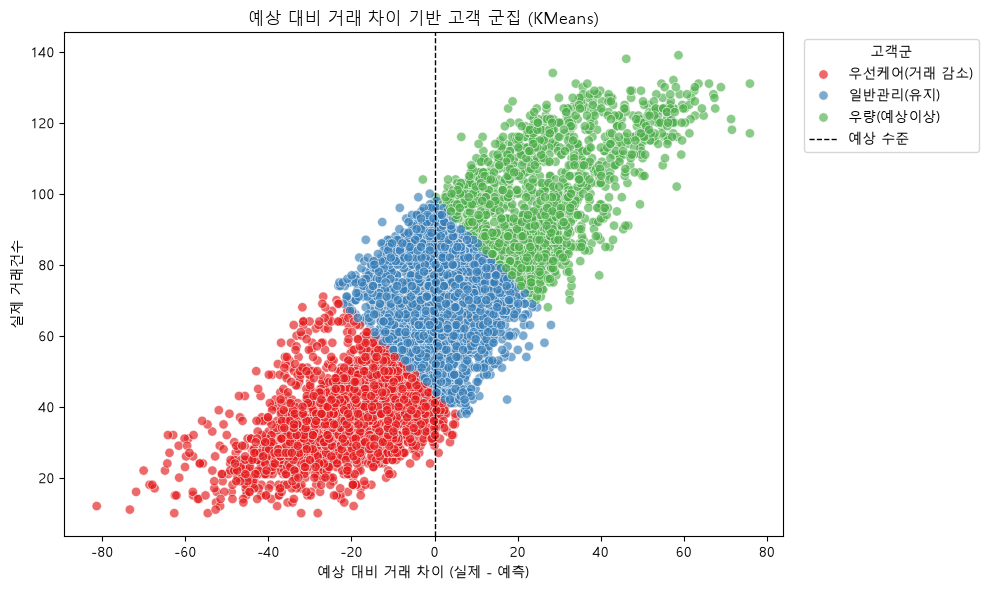

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cluster_df,
    x="예상_대비_거래_차이",
    y="실제_거래건수",
    hue="비즈니스_라벨",
    palette="Set1",
    alpha=0.65,
    s=45,
)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="예상 수준")
plt.title(f"예상 대비 거래 차이 기반 고객 군집 ({BEST_MODEL})")
plt.xlabel("예상 대비 거래 차이 (실제 - 예측)")
plt.ylabel("실제 거래건수")
plt.legend(title="고객군", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

빨강(우선케어, 거래 감소) 은 점선 왼쪽에 몰려 있으면서 세로로는 60~110 구간에 있습니다. 거래량 자체는 많은데 모델 기대치에는 못 미치는 고객들입니다.

파랑(우량, 예상이상) 은 점선 오른쪽이고 세로로도 높은 편입니다. 기대보다 더 쓰는 고객군입니다.

초록(일반관리, 유지) 은 세로축 아래쪽 10~50에 깔려 있고, 가로로는 점선 양쪽에 걸쳐 있습니다. 여기가 이 그래프의 핵심 포인트입니다. 초록은 갭이 아니라 거래량이 적다는 이유로 묶인 군집입니다. 애초에 적게 쓰니 예측도 낮게 나와서 갭이 0 근처에 모입니다.

## 10. 군집별 Silhouette 점검

전체 점수뿐 아니라 각 군집의 평균 Silhouette도 확인합니다. 특정 군집의 평균이 지나치게 낮거나 음수라면 다른 군집과 겹치는 고객이 많다는 의미입니다.

In [15]:
cluster_df["Silhouette"] = silhouette_samples(
    X_cluster_scaled, cluster_df["Cluster"]
)

silhouette_by_cluster = (
    cluster_df.groupby(["Cluster", "비즈니스_라벨"])["Silhouette"]
    .agg(["count", "mean", "min", "max"])
)

print(f"전체 Silhouette: {final_silhouette:.4f}")
silhouette_by_cluster.round(4)

전체 Silhouette: 0.4473


,,count,mean,min,max
Cluster,비즈니스_라벨,,,,
0,일반관리(유지),4677,0.4505,-0.0060,0.6854
1,우선케어(거래 감소),3268,0.5135,-0.0296,0.6806
2,우량(예상이상),2182,0.3414,-0.0550,0.5456


## 11. 결론

- 회귀 모델을 다시 학습하지 않고, `04_regression_final.ipynb`에서 저장한 모델 B(거래금액 제외, 조기경보용)의 예측 결과(`gap_result_B.pkl`)를 그대로 불러와 사용했습니다.
- Train/Validation/Test 구분 없이 **전체 고객**을 대상으로 군집화를 진행했습니다.
- `예상 대비 거래 차이 + 실제 거래건수`를 표준화하여 KMeans와 GMM을 k=2~8 범위에서 비교했습니다.
- Silhouette만 보면 k=2(약 0.52)가 가장 높았지만, **3단계 비즈니스 해석(우선케어·일반관리·우량)**이 더 실용적이라고 판단해 k=3(KMeans, Silhouette 0.4449)을 최종 모델로 선택했습니다. k=3도 목표 기준(0.4 이상)을 충족합니다.
- 최종 군집을 **우선케어(거래 감소) · 일반관리(유지) · 우량(예상이상)** 고객군으로 해석했습니다.